Análise dos dados para tratamento estatístico

In [ ]:
import pandas as pd
import geopandas as gpd

path = '/home/vinicius/projects/projects/gee-data-pipeline/saidas/subbacias_corrigidas_com_gcn.geojson'

gdf = gpd.read_file(path)
gdf['gcn'] = gdf['gcn'].clip(lower=0, upper=100)

gdf.describe()


In [ ]:
gdf.nlargest(5, 'gcn')

In [ ]:
gdf.nsmallest(5, 'gcn')

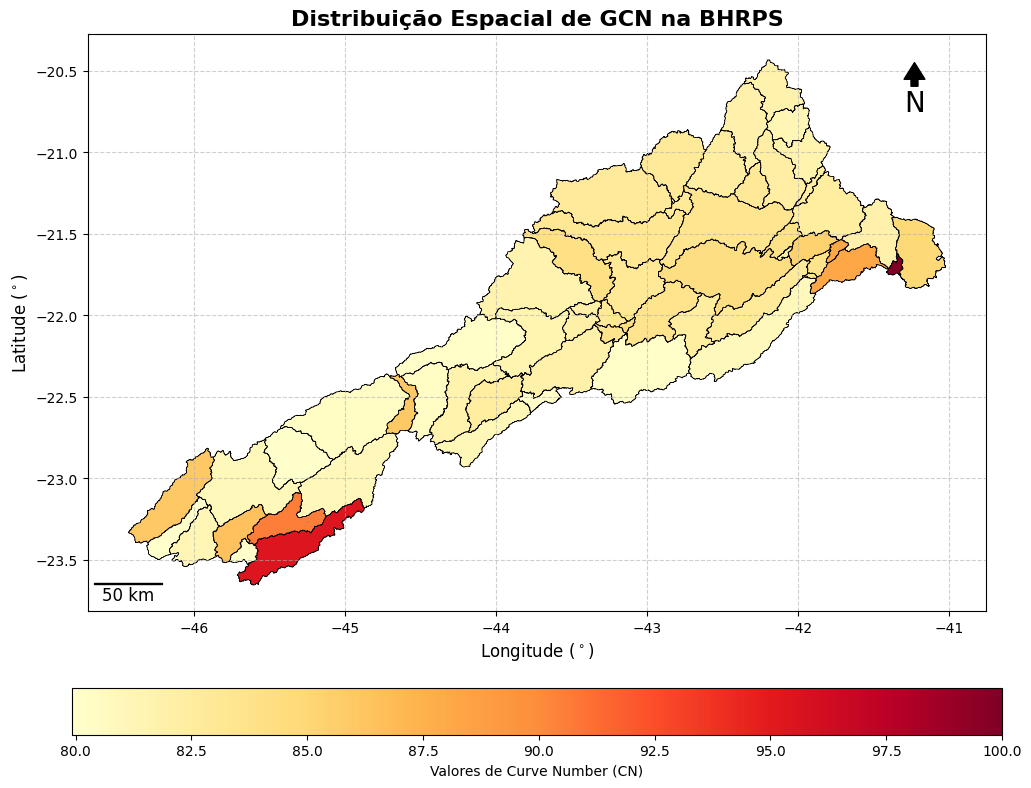

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import os

output_dir = "/home/vinicius/projects/projects/gee-data-pipeline/saidas/graphs"
os.makedirs(output_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 10))

# 2. Plotar o GeoJSON usando o eixo 'ax' criado acima
# O 'clip' garante que o 100.92 seja visualizado como 100 na legenda
gdf.plot(ax=ax,
         column='gcn',
         cmap='YlOrRd',
         legend=True,
         edgecolor='black', # Adiciona bordas finas entre as sub-bacias
         linewidth=0.5,
         legend_kwds={'label': "Valores de Curve Number (CN)", 'orientation': "horizontal", 'pad': 0.1})

# 3. Adicionar e configurar os eixos
ax.set_title('Distribuição Espacial de GCN na BHRPS', fontsize=16, fontweight='bold')
ax.set_xlabel(r'Longitude ($^\circ$)', fontsize=12)
ax.set_ylabel(r'Latitude ($^\circ$)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

x, y, arrow_length = 0.92, 0.95, 0.07
ax.annotate(
    'N', xy=(x, y), xytext=(x, y - arrow_length),
    arrowprops=dict(facecolor='black', width=5, headwidth=15),
    ha='center', va='center', fontsize=20,
    xycoords=ax.transAxes
)


# Configuração da barra: 0.45 graus aprox 50km na latitude da BHRPS
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           0.45, '50 km', 'lower left',
                           pad=0.3,
                           color='black',
                           frameon=False,
                           size_vertical=0.005,
                           fontproperties=fontprops)

ax.add_artist(scalebar)

caminho_salvamento = os.path.join(output_dir, 'mapa_gcn_final.png')
plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')

plt.show()

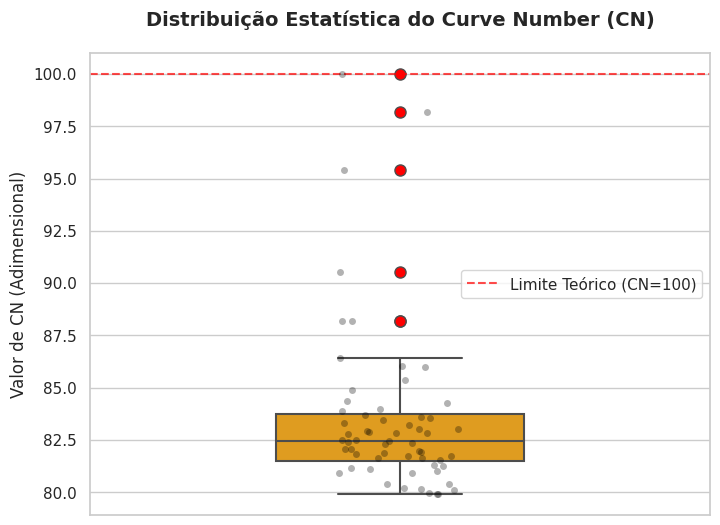

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo acadêmico
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Criando o Boxplot
sns.boxplot(y=gdf['gcn'],
            color='orange',
            width=0.4,
            linewidth=1.5,
            flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})

# Opcional: Adicionar os pontos (sub-bacias) sobre o boxplot para mostrar a densidade
sns.stripplot(y=gdf['gcn'], color='black', alpha=0.3, jitter=True)

# Configurações de eixos e títulos
ax.set_title('Distribuição Estatística do Curve Number (CN)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Valor de CN (Adimensional)', fontsize=12)

# Adicionando uma linha tracejada no limite teórico de 100
ax.axhline(100, color='red', linestyle='--', alpha=0.7, label='Limite Teórico (CN=100)')
ax.legend()

# Salvar para o Overleaf

caminho_salvamento = os.path.join(output_dir, 'boxplot_gcn_tcc.png')
plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
plt.show()

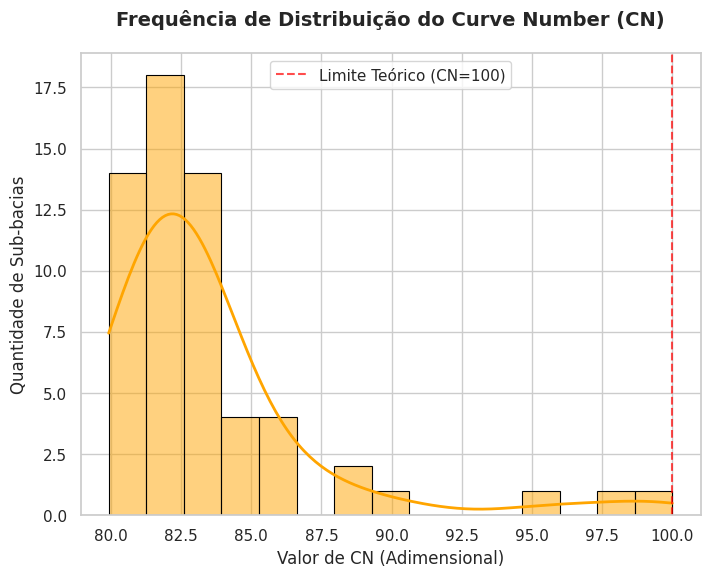

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo acadêmico
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Criando o Histograma com a linha de densidade (KDE)
sns.histplot(x=gdf['gcn'],
             kde=True,
             color='orange',
             bins=15,  # Define a quantidade de faixas (barras)
             edgecolor='black',
             linewidth=0.8,
             line_kws={"linewidth": 2}) # Espessura da linha de densidade

# Configurações de eixos e títulos
ax.set_title('Frequência de Distribuição do Curve Number (CN)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Valor de CN (Adimensional)', fontsize=12)
ax.set_ylabel('Quantidade de Sub-bacias', fontsize=12)

# Adicionando a linha tracejada no limite teórico de 100 para manter a consistência com o Boxplot
ax.axvline(100, color='red', linestyle='--', alpha=0.7, label='Limite Teórico (CN=100)')
ax.legend()

# Salvar para o Overleaf em alta resolução (300 DPI)
caminho_salvamento = os.path.join(output_dir, 'histograma_gcn_tcc.png')
plt.savefig(caminho_salvamento, dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 1. Obter estatísticas básicas
stats = gdf['gcn'].describe()

# 2. Calcular o Coeficiente de Variação (CV) em porcentagem
cv = (stats['std'] / stats['mean']) * 100

# 3. Mostrar os resultados formatados para a sua tabela
print("-" * 30)
print("ESTATÍSTICAS PARA O TCC")
print("-" * 30)
print(f"Contagem: {int(stats['count'])}")
print(f"Média: {stats['mean']:.2f}")
print(f"Desvio Padrão: {stats['std']:.2f}")
print(f"CV: {cv:.2f}%")
print(f"Mínimo: {stats['min']:.2f}")
print(f"25% (Q1): {stats['25%']:.2f}")
print(f"50% (Mediana): {stats['50%']:.2f}")
print(f"75% (Q3): {stats['75%']:.2f}")
print(f"Máximo: {stats['max']:.2f}")
print("-" * 30)

------------------------------
ESTATÍSTICAS PARA O TCC
------------------------------
Contagem: 60
Média: 83.51
Desvio Padrão: 3.96
CV: 4.74%
Mínimo: 79.92
25% (Q1): 81.50
50% (Mediana): 82.47
75% (Q3): 83.73
Máximo: 100.00
------------------------------
